# cosine correction comparison

## read cosine corrected

In [1]:
import atmPy.radiation.retrievals.spectral_irradiance as atmsi

In [2]:
import atmPy.general.measurement_site as atmsite

In [3]:
plt.rcParams['figure.dpi'] = 200

/var/folders/f4/dl3whmyd1rj_9smbyhmyqyj1h26f40/T/ipykernel_24259/792834036.py:6: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(fl[slice(i,i+2)])


11
2026-03-03 00:00:00


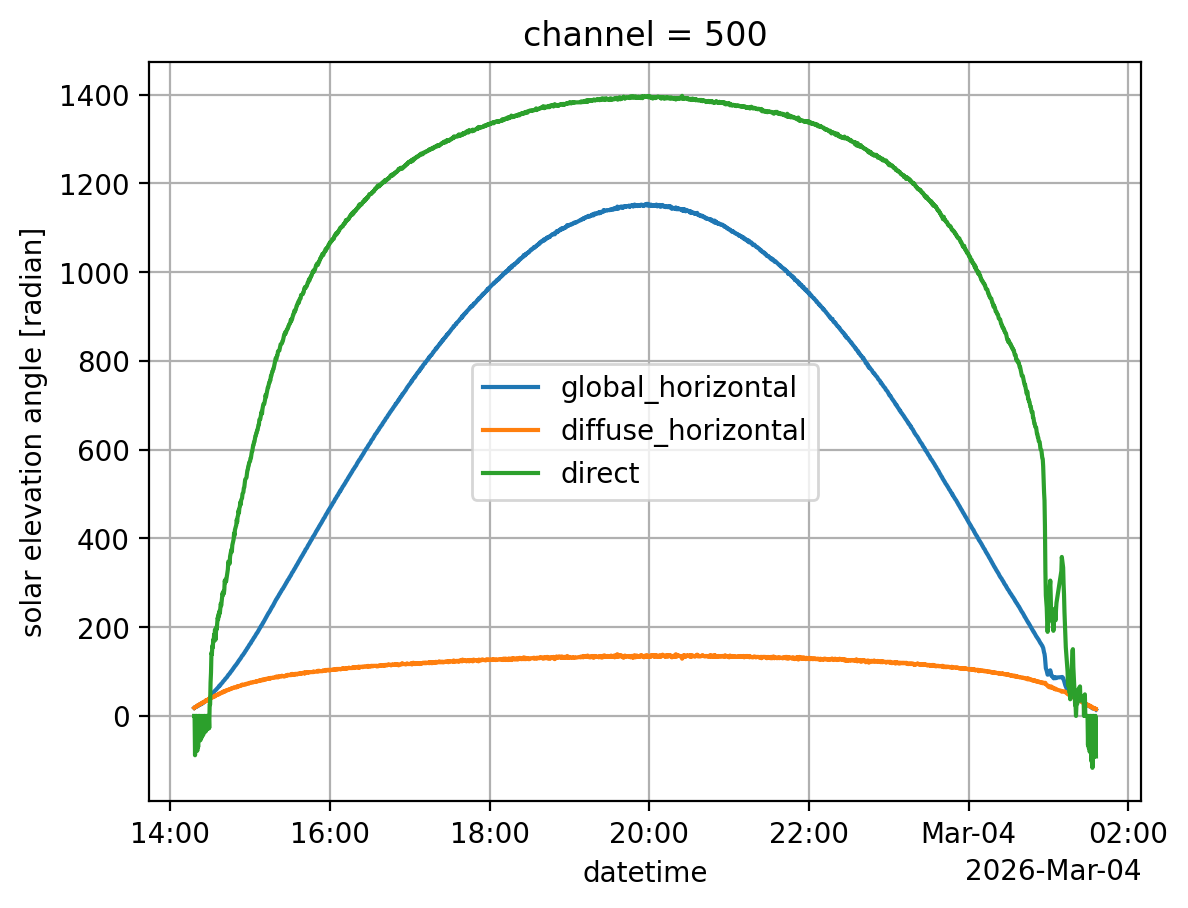

In [4]:
i = 11
# i += 1
p2fld = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/dra/mfrsr/cosine_corrected/v0.1/2026/')
fl = list(p2fld.glob('*.nc'))
fl.sort()
ds = xr.open_mfdataset(fl[slice(i,i+2)])

site = atmsite.Station(lat = ds.site_latitude, lon = ds.site_longitude, name = ds.site_name)
tdiff = pd.to_timedelta(site.time_zone['diff2UTC_of_standard_time'], 'h')
dt_local = pd.DatetimeIndex(ds.datetime + tdiff)
start = dt_local[0].ceil("D")
end = start  + pd.to_timedelta(1, 'D') - pd.to_timedelta(1, 'ns')
assert(start.date() == end.date()), f'Start ({start}) and end ({end}) timestamps are on different days, this should not happen!?!'
ds = ds.sel(datetime = slice(start - tdiff, end - tdiff))
print(i)
print(start)

# ds = xr.open_dataset(p2f)
dscc = atmsi.CombinedGlobalDiffuseDirect(ds)
dscc.plot_overview()
None

In [5]:
import atmPy.data_archives.NOAA_ESRL_GMD_GRAD.surfrad.surfrad as atmsrf

In [14]:
# si_tu = atmsrf.read_ccc(pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/tu/2026/tbl_mfrsr_20260106_D824_3126_660.tu'), raisefilterfunctionerror=False)
si_tu = atmsrf.read_ccc(pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/dra/mfrsr/tu/2026/dra_mfrsr_20260303_2089_718C_669.tu'), raisefilterfunctionerror=False)
tu_raw = si_tu.dataset.copy()
si_tu.dataset = si_tu.dataset.reindex(datetime = dscc.dataset.datetime, method='bfill')
si_tu.dataset = si_tu.dataset.rename({'direct_normal_irradiation': 'direct_normal', 'diffuse_horizontal_irradiation': 'diffuse_horizontal', 'global_horizontal_irradiation': 'global_horizontal'})

Text(0, 0.5, 'irradiance (mV)')

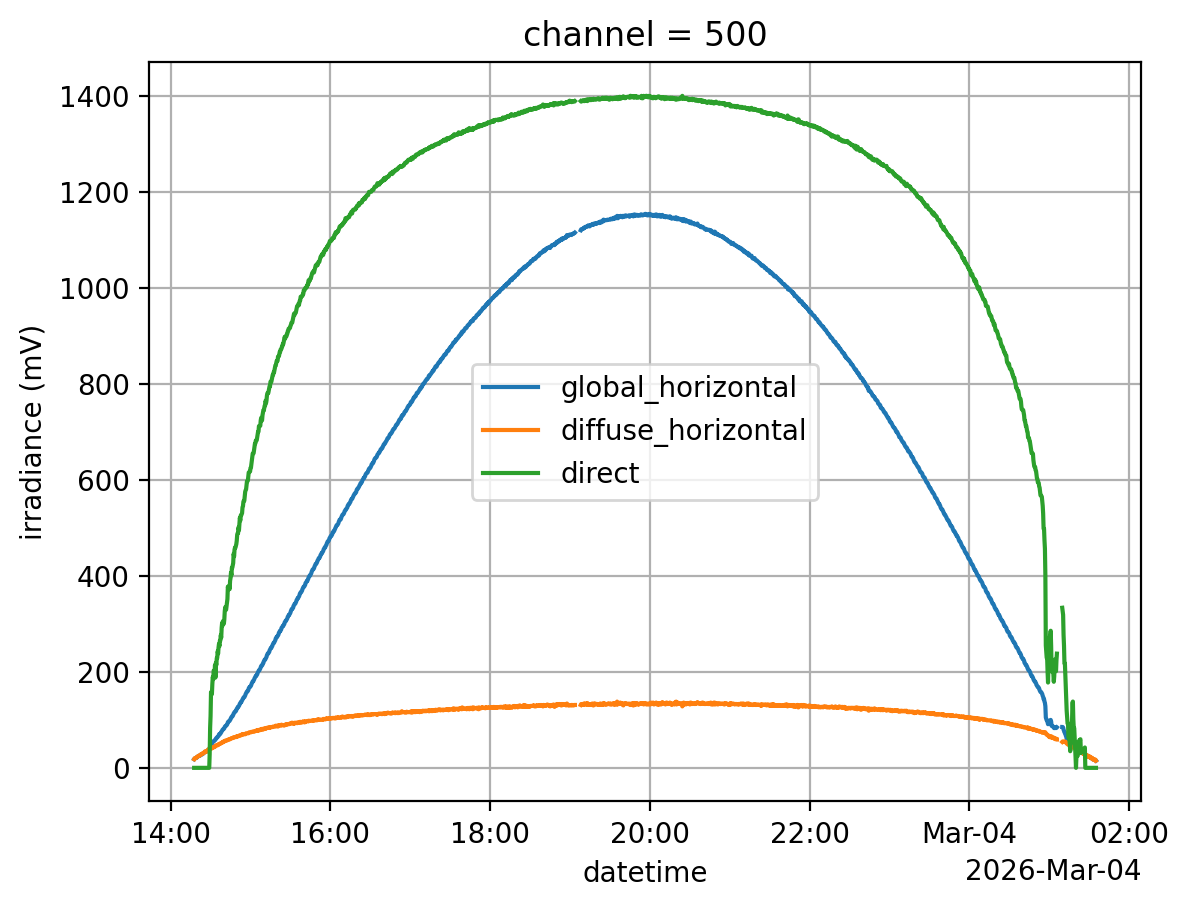

In [7]:
f,a = si_tu.plot_overview(channel=500)
a.set_ylabel('irradiance (mV)')

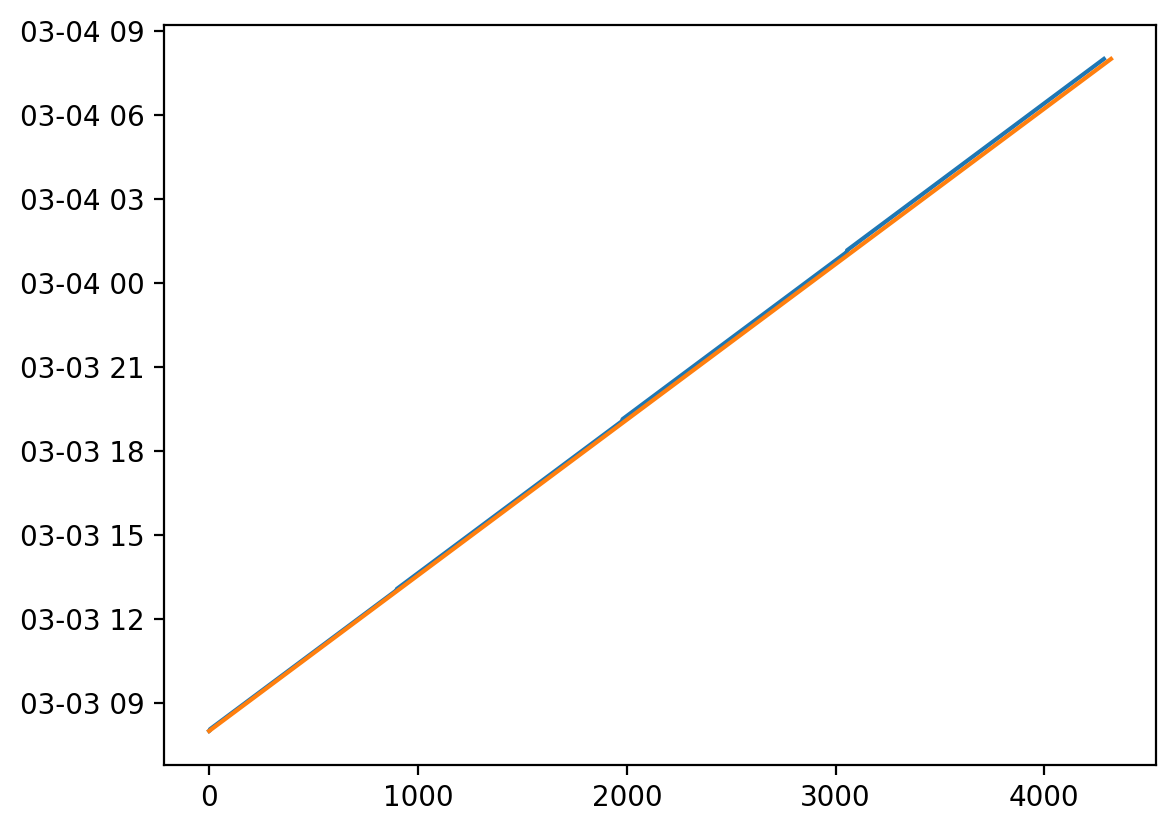

In [8]:
f,a = plt.subplots()
a.plot(dscc.dataset.datetime)
a.plot(tu_dt)

In [11]:
%matplotlib widget

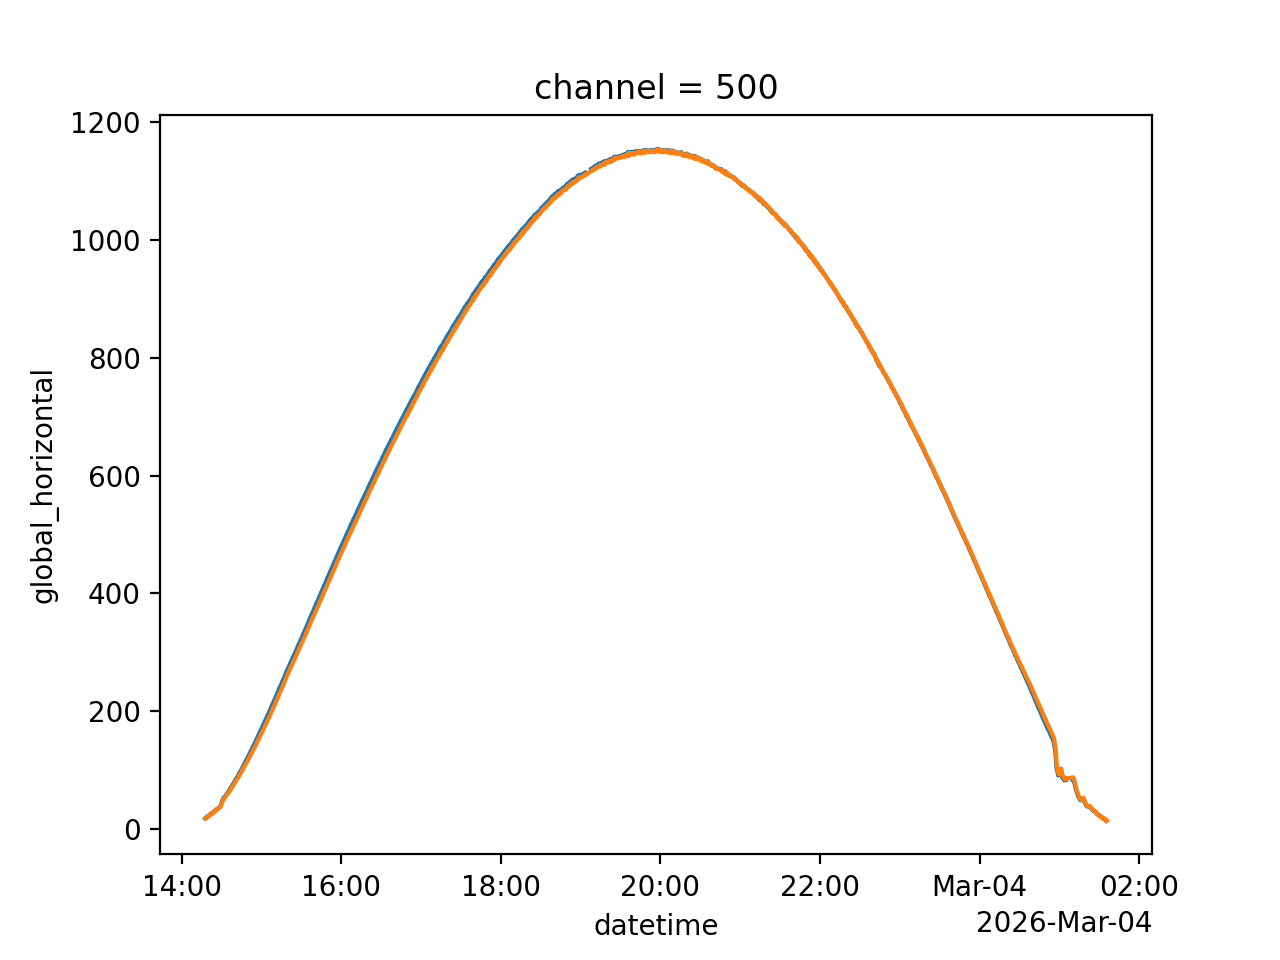

In [18]:
f,a = plt.subplots()
wl = 500
tu_raw.global_horizontal_irradiation.sel(channel = wl).plot(ax = a)
# dscc.dataset.global_horizontal_irradiation.sel(channel = wl).plot(ax = a)
dscc.dataset.global_horizontal.sel(channel = wl).plot(ax = a)

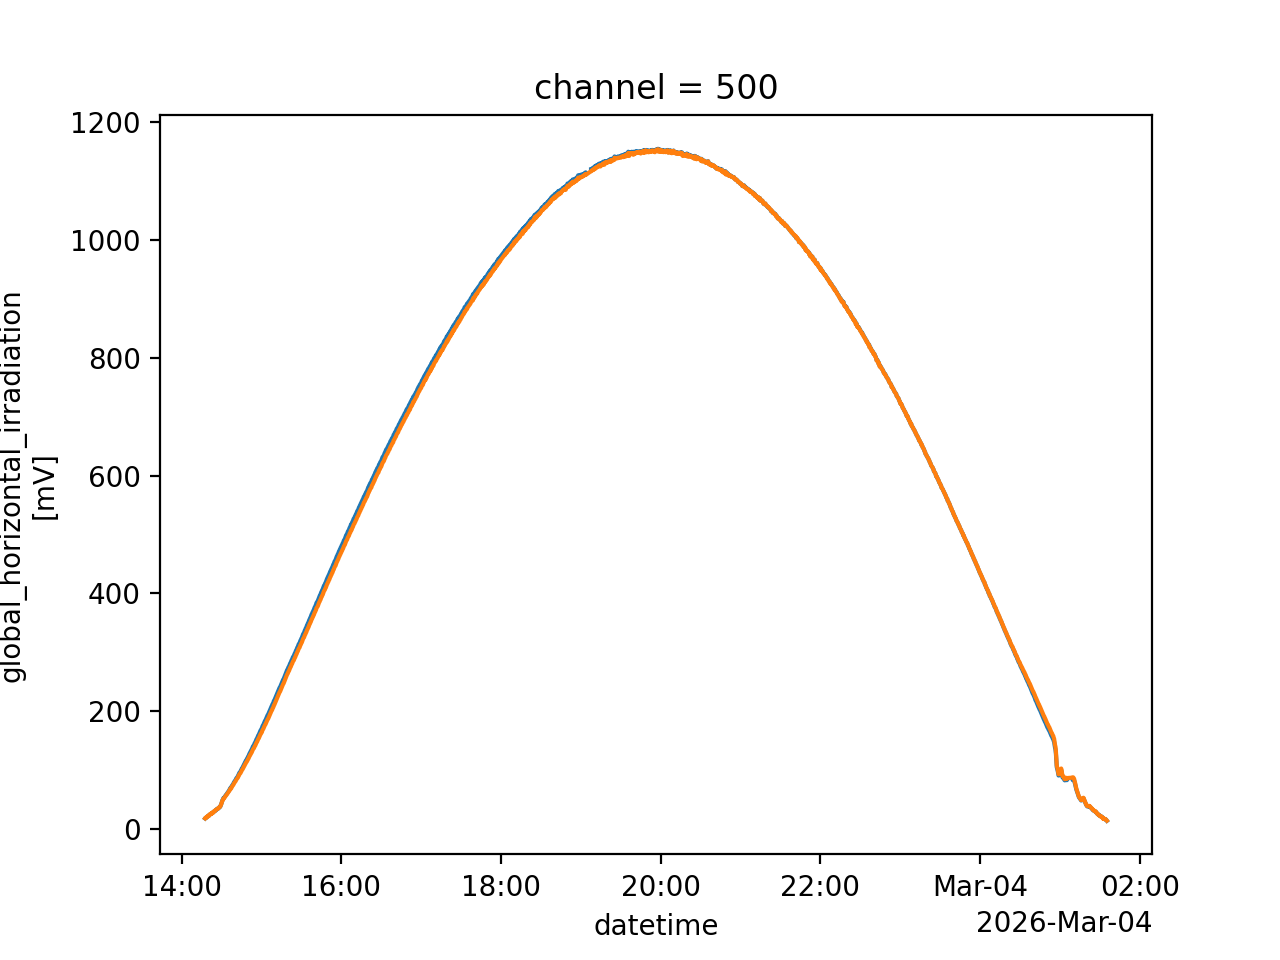

In [20]:
f,a = plt.subplots()
wl = 500
tu_raw.global_horizontal_irradiation.sel(channel = wl).plot(ax = a)
# dscc.dataset.global_horizontal_irradiation.sel(channel = wl).plot(ax = a)
das = dscc.dataset.global_horizontal.sel(channel = wl)
a.plot(das.datetime - pd.to_timedelta(20, 's'), das)

# Langleys

## am

In [20]:
amr = [2.2,5]

In [21]:
dscc.direct_normal_irradiation._am = None
dscc.direct_normal_irradiation._pm = None
dscc.direct_normal_irradiation.settings_langley_airmass_limits = amr

In [22]:
si_tu.direct_normal_irradiation._am = None
si_tu.direct_normal_irradiation._pm = None
si_tu.direct_normal_irradiation.settings_langley_airmass_limits = amr

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

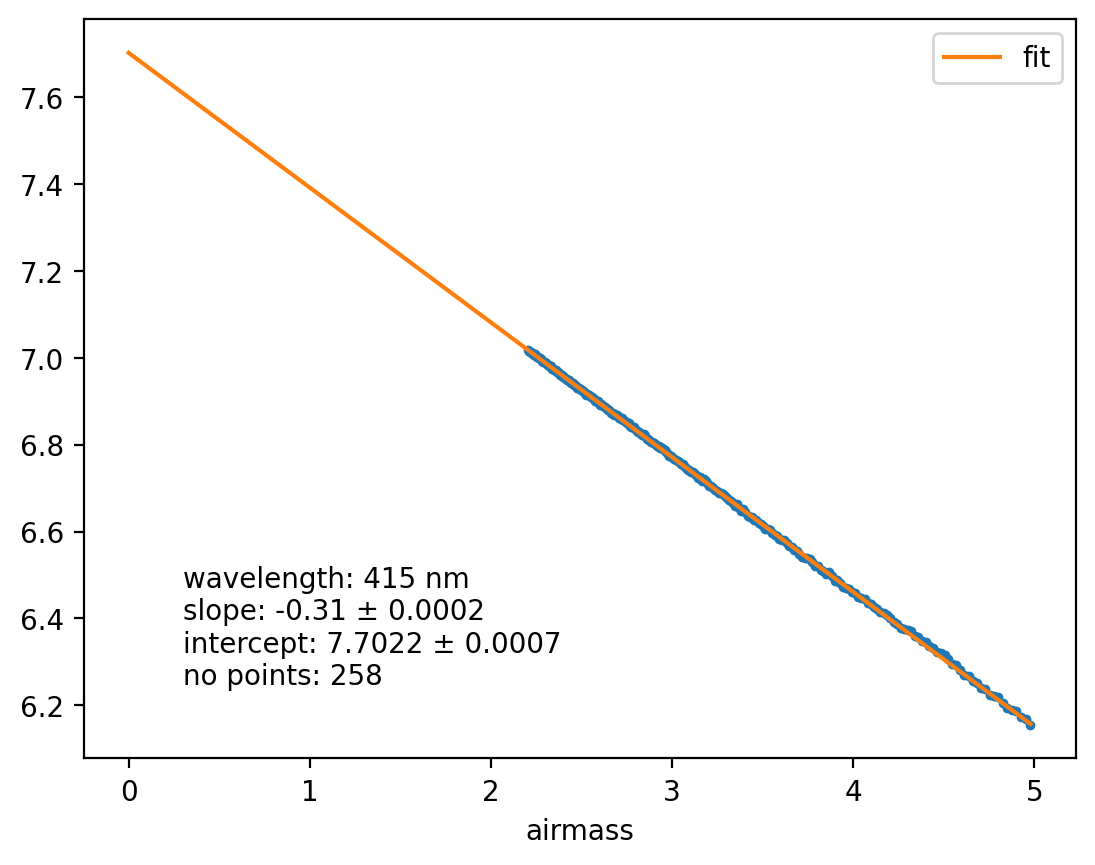

In [35]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=415, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

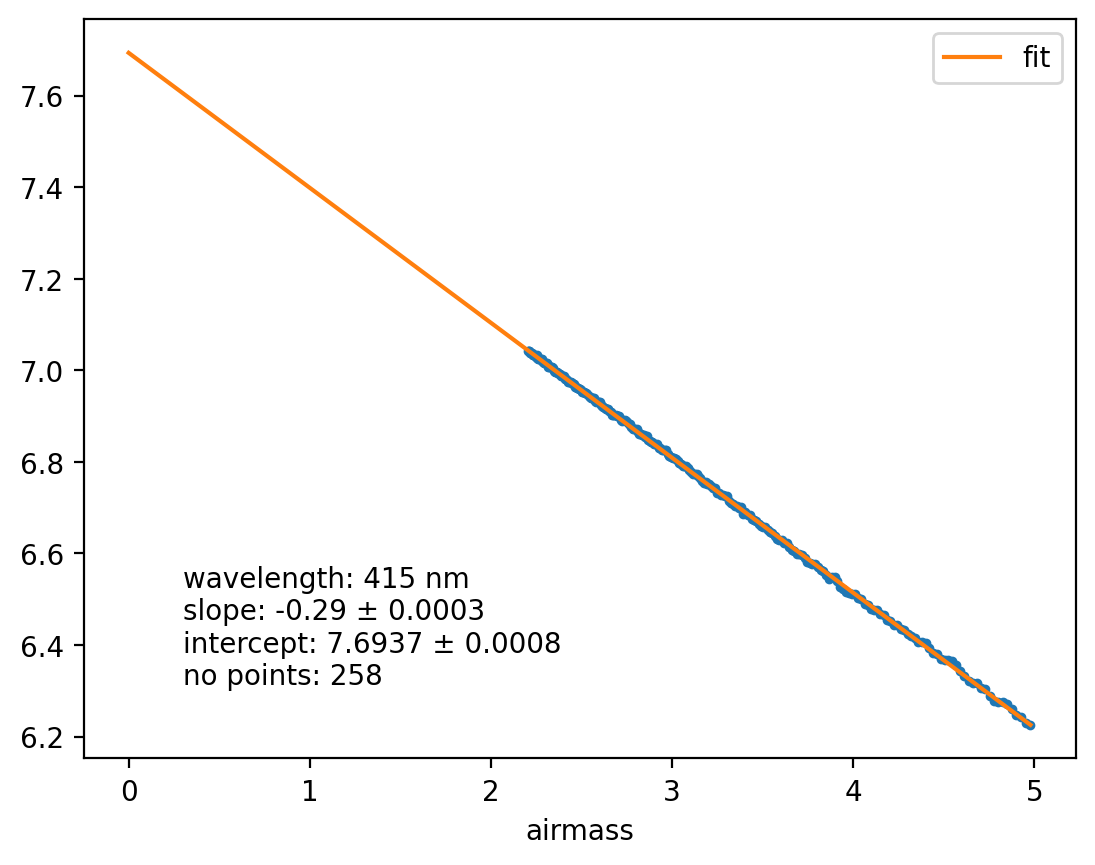

In [36]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=415, show_pre_clean=False)

In [23]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=500, show_pre_clean=False)

In [25]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

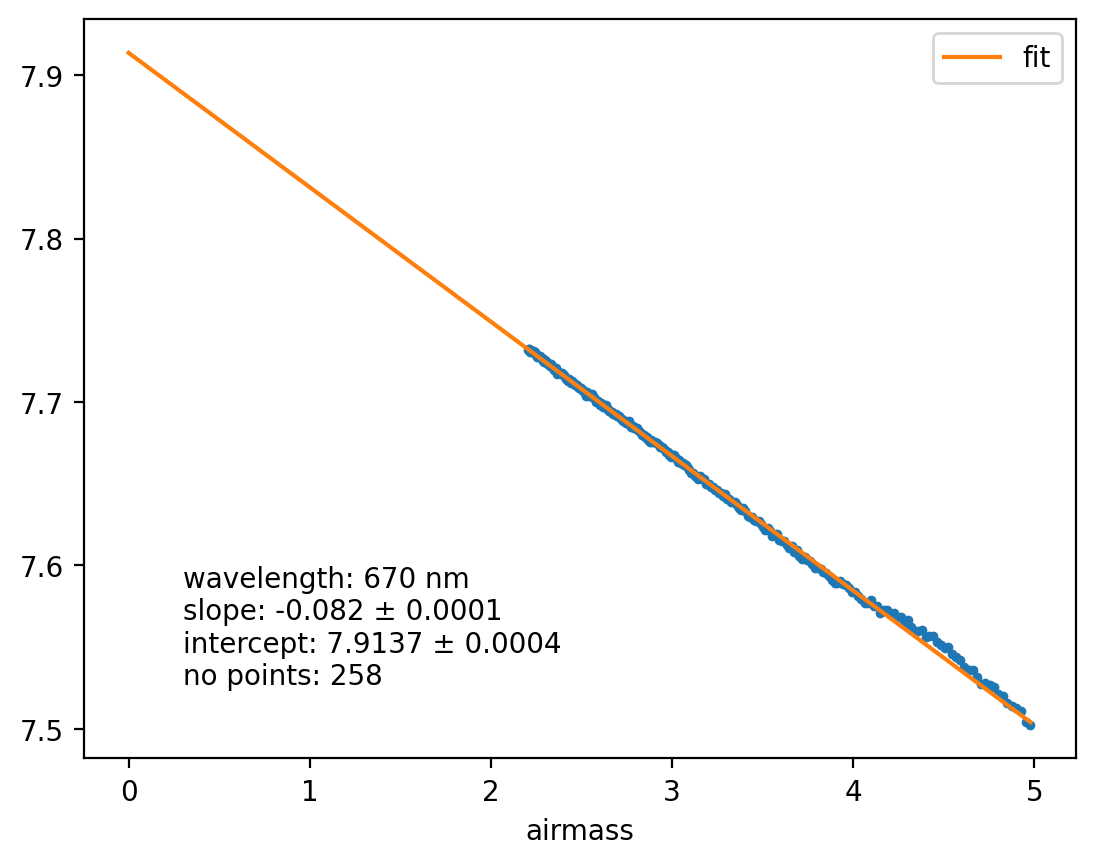

In [37]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=670, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

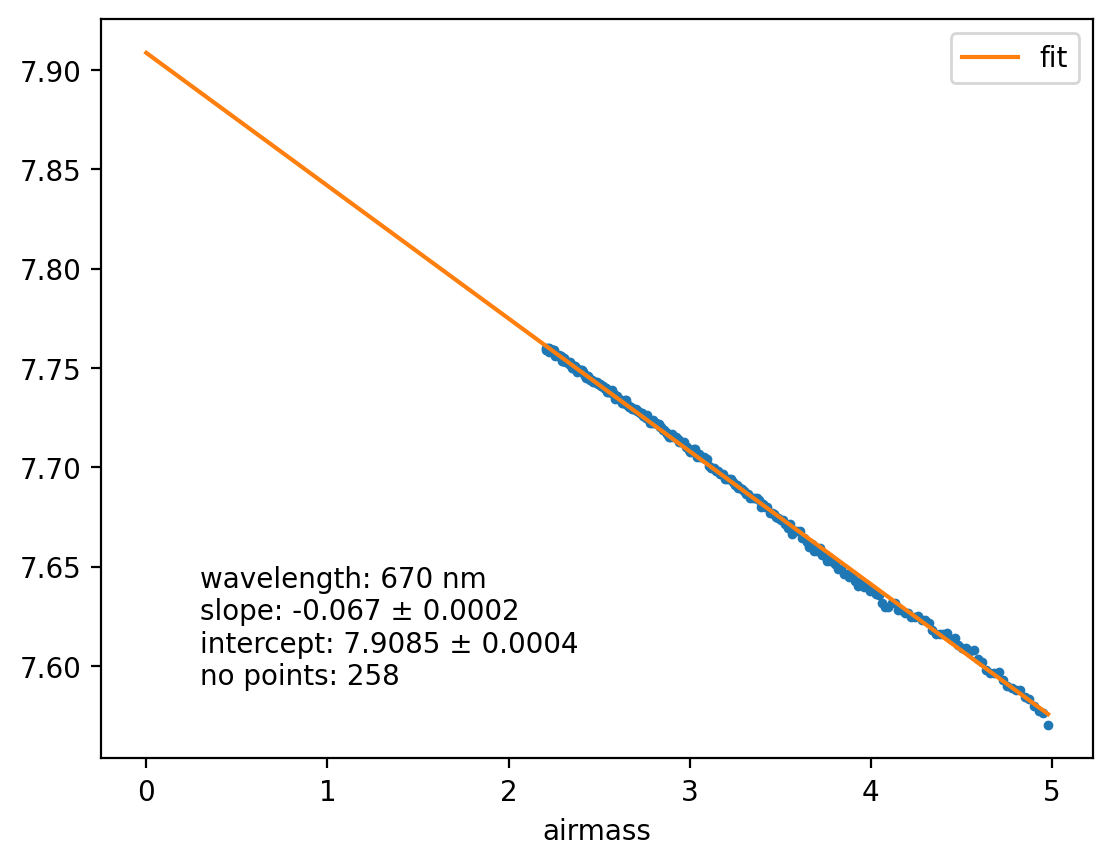

In [38]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=670, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

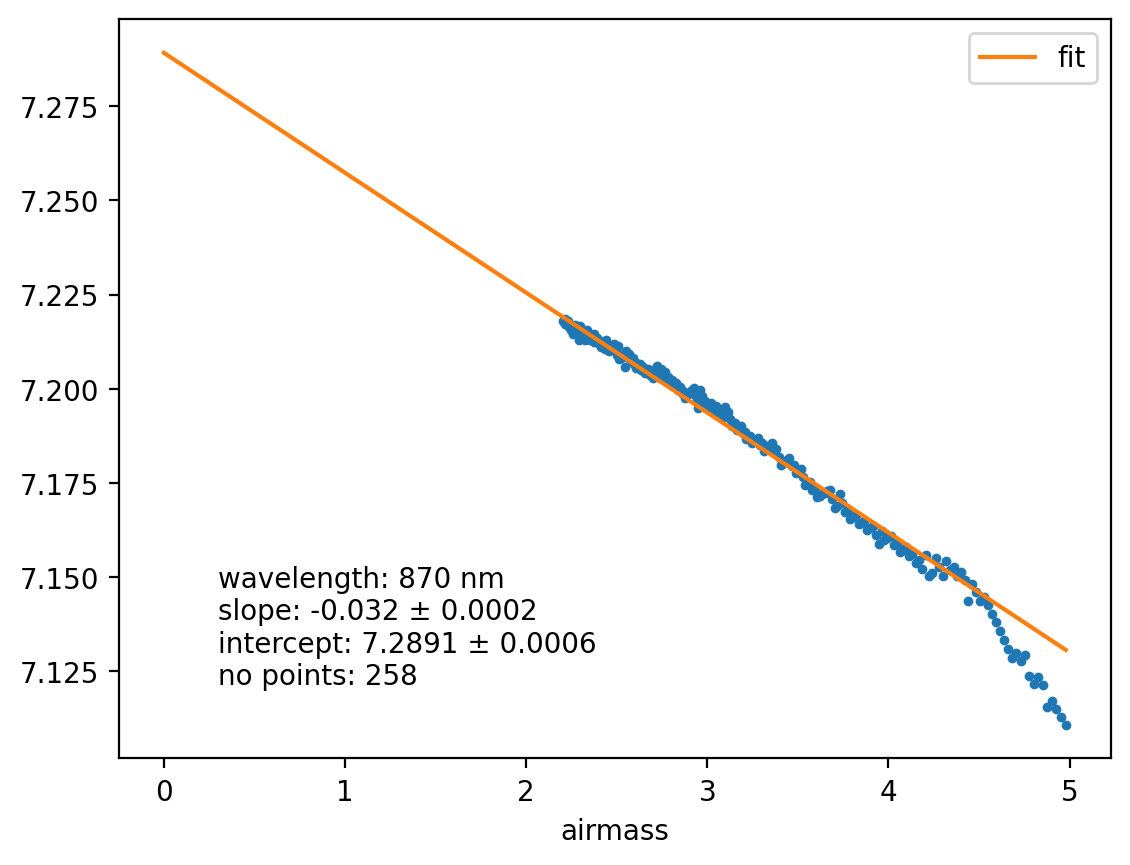

In [24]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

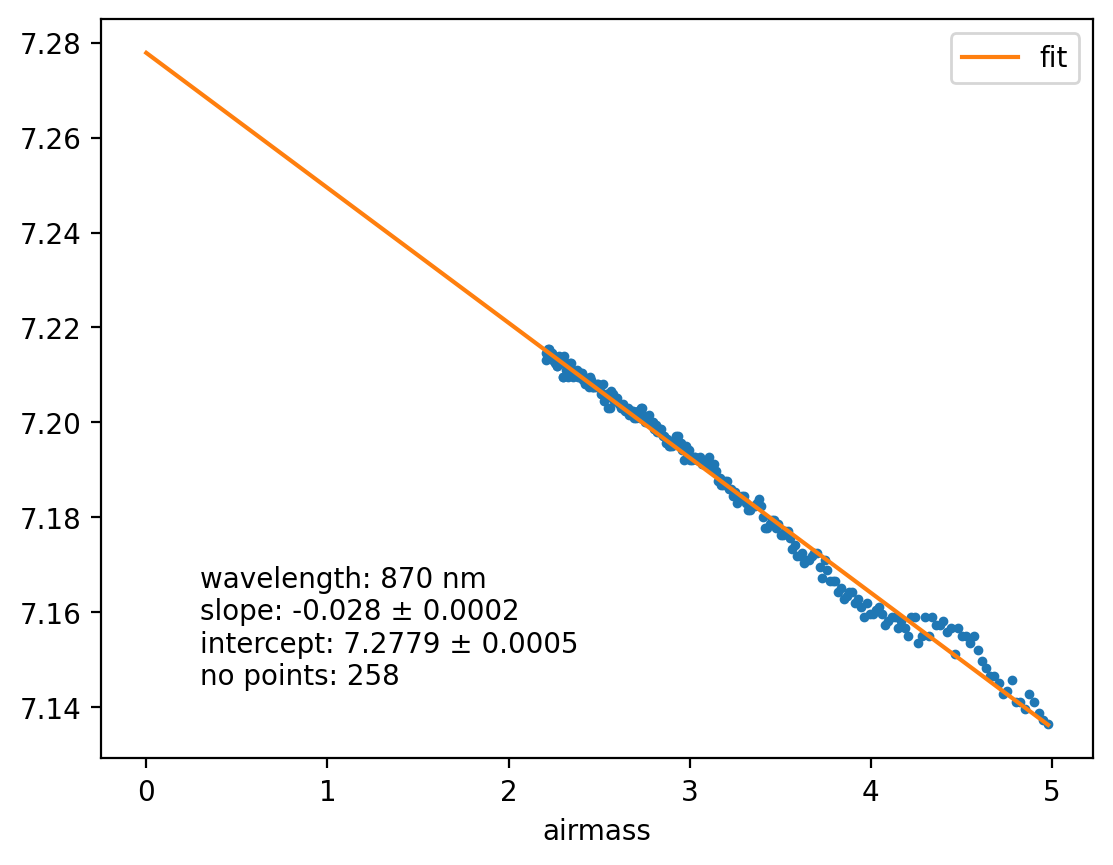

In [26]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

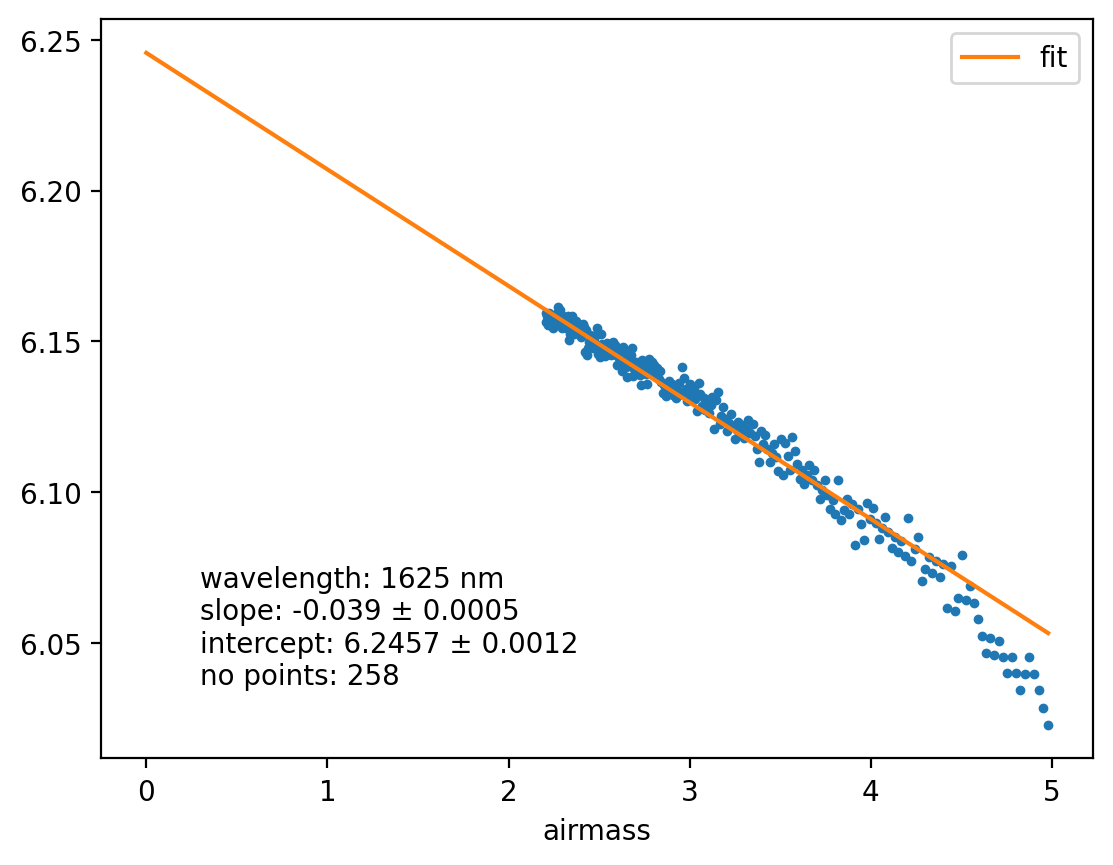

In [43]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=1625, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

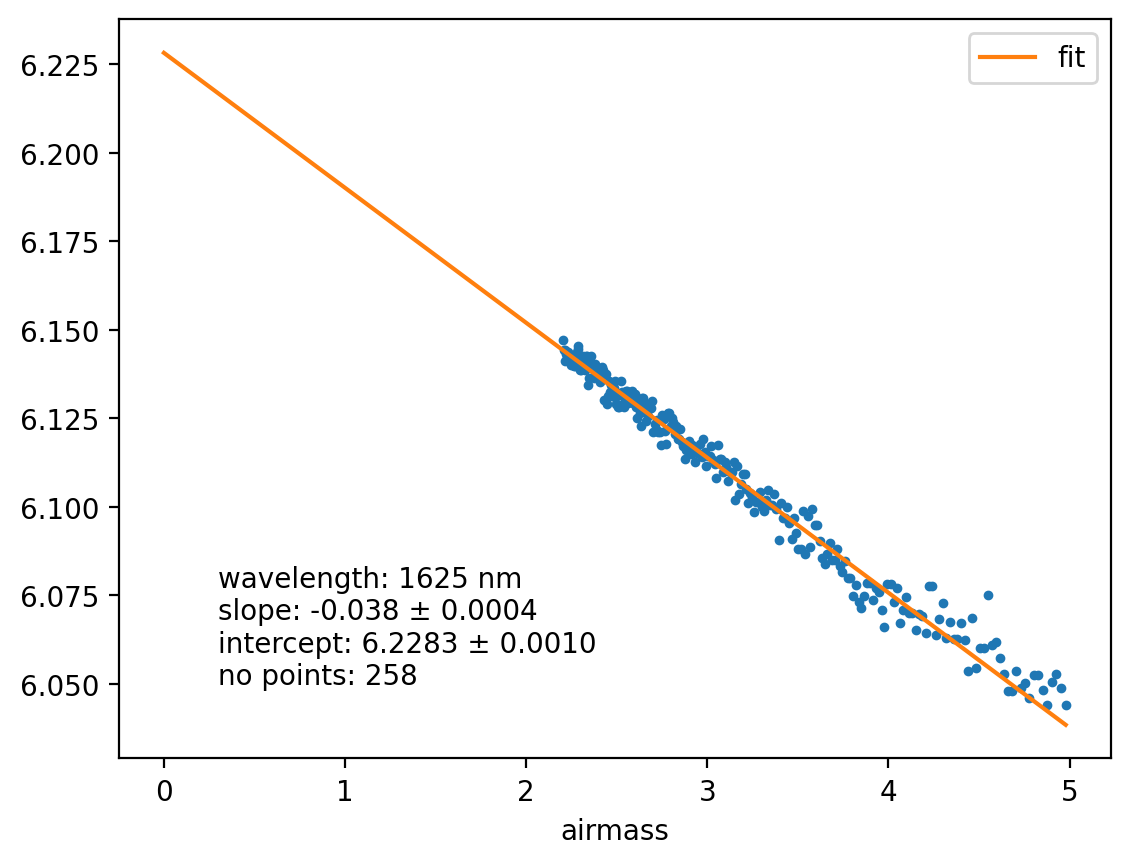

In [42]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=1625, show_pre_clean=False)

## pm

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

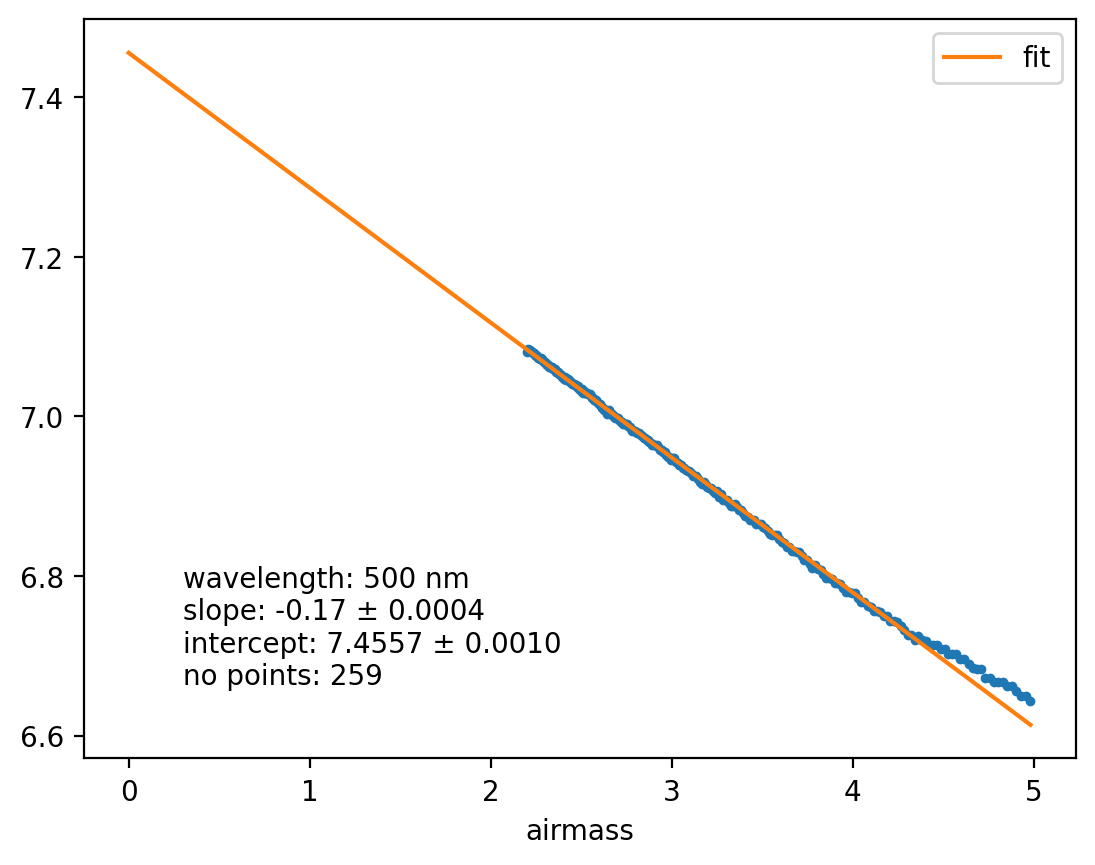

In [27]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

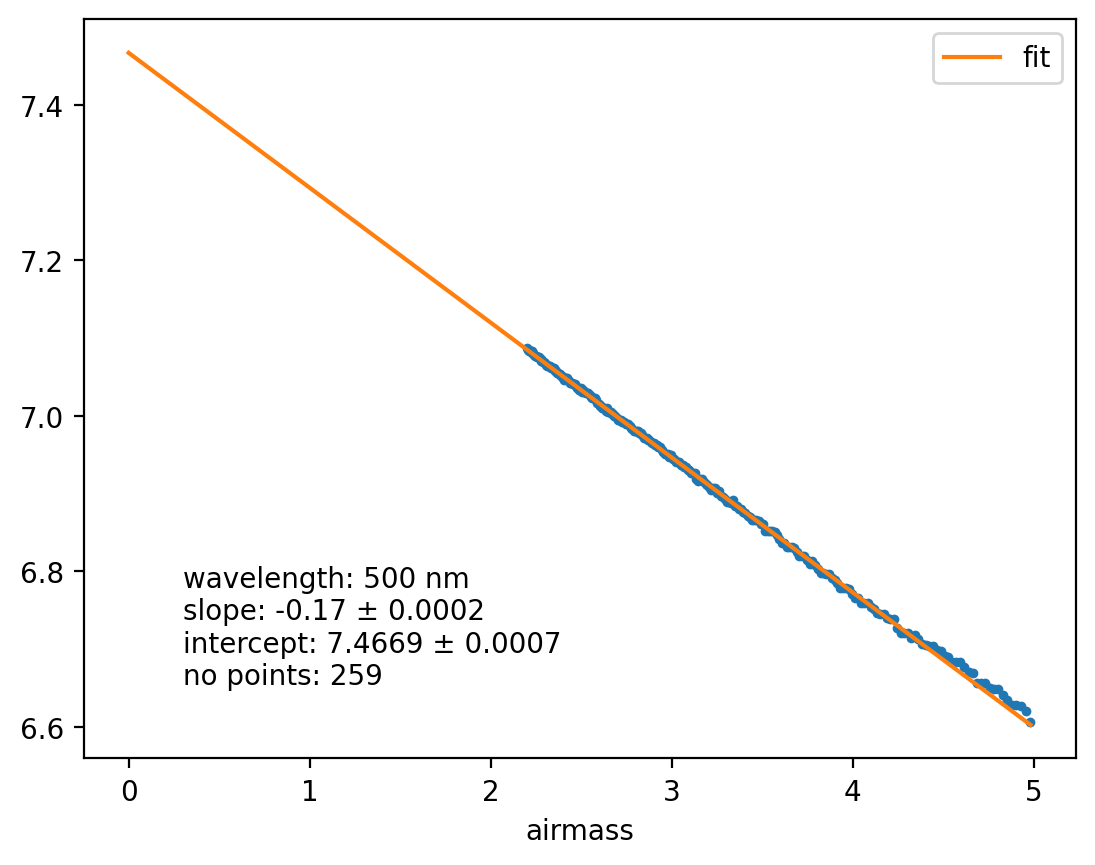

In [29]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

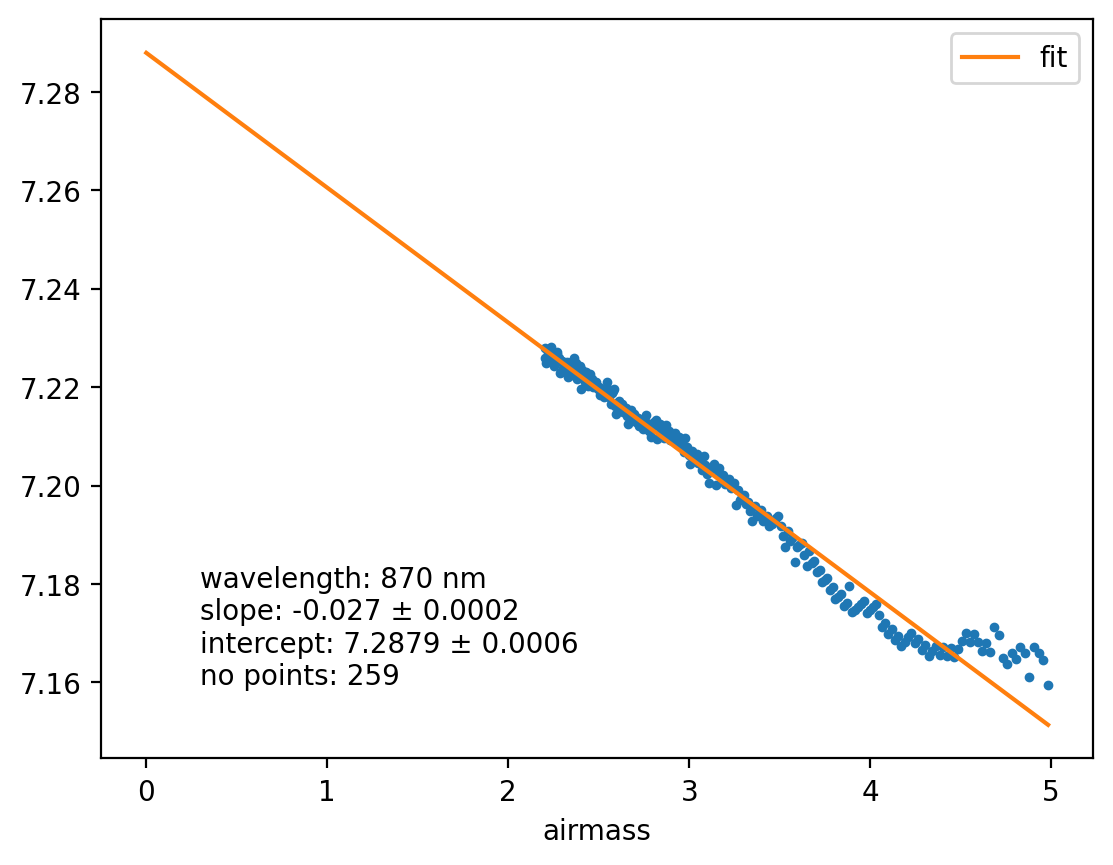

In [28]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

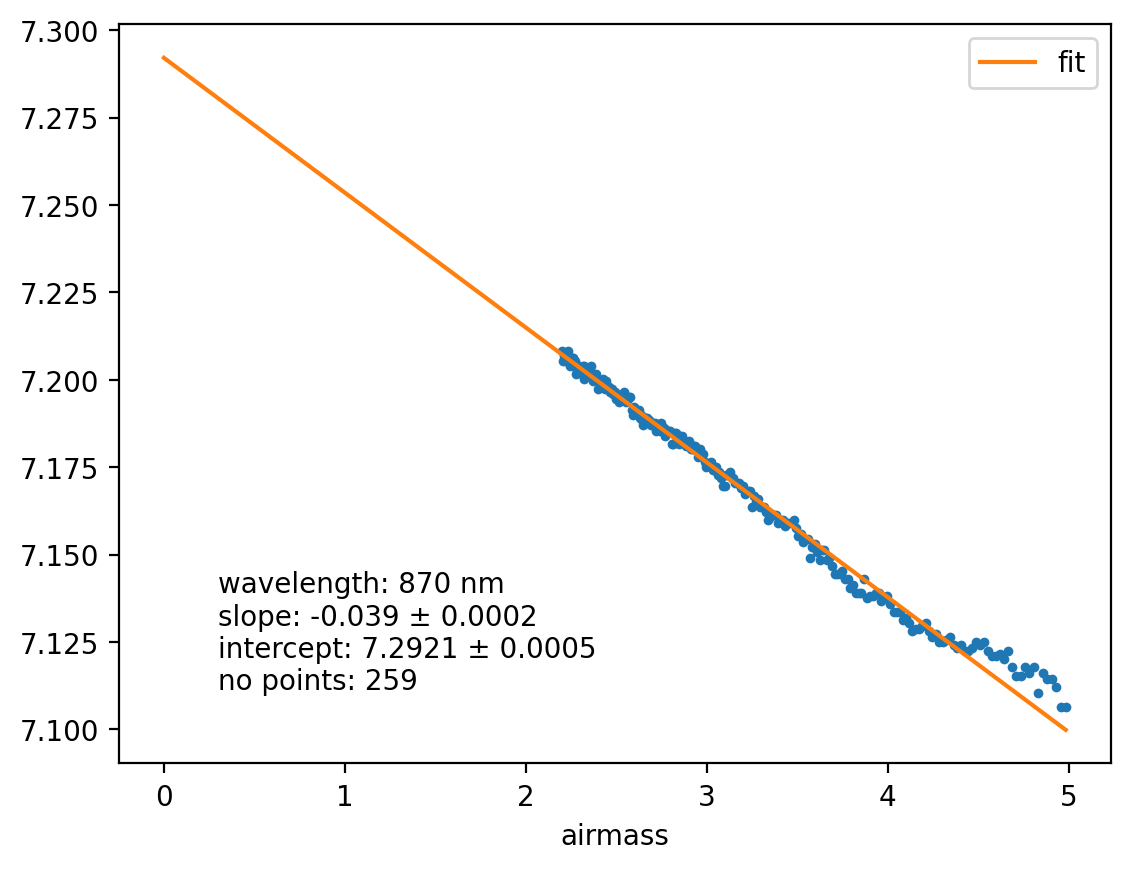

In [30]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=870, show_pre_clean=False)

In [34]:
df = pd.DataFrame()
df['dscc_am'] = dscc.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['tu_am'] = si_tu.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['dscc_pm'] = dscc.direct_normal_irradiation.langley_pm.langley_fitres.intercept
df['tu_pm'] = si_tu.direct_normal_irradiation.langley_pm.langley_fitres.intercept

# df['tu_ratio'] = df.tu_am/df.tu_pm
# df['tu_dif'] = df.tu_am - df.tu_pm
# df['dscc_dif'] = df.dscc_am - df.dscc_pm

df['tu_dif'] = np.exp(df.tu_am) - np.exp(df.tu_pm)
df['dscc_dif'] = np.exp(df.dscc_am) - np.exp(df.dscc_pm)

df['tu_uc'] = df.tu_dif / np.exp(df.tu_am)
df['dscc_uc'] = df.dscc_dif / np.exp(df.dscc_am)

df['tuVSdscc'] = abs(((np.exp(df['dscc_am']) + np.exp(df['dscc_pm']))/2) - ((np.exp(df['tu_am']) + np.exp(df['tu_pm']))/2))
df['tuVSdscc_rel'] = df.tuVSdscc / np.exp((df['dscc_am'] + df['dscc_pm'])/2)

df

,dscc_am,tu_am,dscc_pm,tu_pm,tu_dif,dscc_dif,tu_uc,dscc_uc,tuVSdscc,tuVSdscc_rel
wavelength,,,,,,,,,,
415,7.702239,7.693697,7.706673,7.722899,-65.028809,-9.835325,-0.029633,-0.004444,8.770774,0.003954
500,7.453911,7.445264,7.455690,7.466935,-37.499951,-3.074215,-0.021908,-0.001780,2.346937,0.001358
670,7.913653,7.908507,7.913874,7.925028,-45.315865,-0.605447,-0.016658,-0.000221,8.321226,0.003043
870,7.289136,7.277860,7.287937,7.292088,-20.747962,1.754492,-0.014330,0.001198,5.167731,0.003531
940,7.380072,7.368544,7.375153,7.385806,-27.603777,7.868589,-0.017412,0.004907,0.644374,0.000403
1625,6.245711,6.228273,6.233900,6.230745,-1.254664,6.056577,-0.002475,0.011742,5.261133,0.010260
